In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("Shipment Data.csv")

In [3]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10901 non-null  float64
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10845 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10860 non-null  float64
 11  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


In [5]:
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10901.000000,10999.000000,10999.000000,10860.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.194386,3.567597,13.373216,3641.667035,0.596691
std,3175.28214,1.141490,1.413603,48.063598,1.522860,16.205527,1635.078989,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1843.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4157.500000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5058.250000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7684.000000,1.000000


In [6]:
data['Reached.on.Time_Y.N'].value_counts()

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

In [8]:
#Missing value imputation for numerical data
data['Cost_of_the_Product'] = data['Cost_of_the_Product'].fillna(data['Cost_of_the_Product'].median())
data['Weight_in_gms'] = data['Weight_in_gms'].fillna(data['Weight_in_gms'].median())

In [9]:
#Missing value imputation for catgorical data
product_imporatance=data['Product_importance'].mode()
print(product_imporatance)
data['Product_importance'].value_counts()
data['Product_importance'] = data['Product_importance'].fillna(data['Product_importance'].mode()[0])

0    low
Name: Product_importance, dtype: object


In [10]:
data.drop(columns=['ID'], inplace=True)

In [11]:
data.isnull().sum()

Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [12]:
data.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.228293,3.567597,13.373216,3648.185881,0.596691
std,1.141490,1.413603,47.850315,1.522860,16.205527,1625.735062,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,170.000000,3.000000,4.000000,1854.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4157.500000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5042.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7684.000000,1.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_block      10999 non-null  object 
 1   Mode_of_Shipment     10999 non-null  object 
 2   Customer_care_calls  10999 non-null  int64  
 3   Customer_rating      10999 non-null  int64  
 4   Cost_of_the_Product  10999 non-null  float64
 5   Prior_purchases      10999 non-null  int64  
 6   Product_importance   10999 non-null  object 
 7   Gender               10999 non-null  object 
 8   Discount_offered     10999 non-null  int64  
 9   Weight_in_gms        10999 non-null  float64
 10  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 945.4+ KB


In [14]:
#one hot encoding for categorical data
categorical_features =['Warehouse_block','Mode_of_Shipment','Product_importance','Gender']
data = pd.get_dummies(data, columns =categorical_features, drop_first= False)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [15]:
data.head(5)

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium,Gender_F,Gender_M
0,4,2,177.0,3,44,1233.0,1,0,0,0,1,0,1,0,0,0,1,0,1,0
1,4,5,216.0,2,59,3088.0,1,0,0,0,0,1,1,0,0,0,1,0,0,1
2,2,2,183.0,4,48,3374.0,1,1,0,0,0,0,1,0,0,0,1,0,0,1
3,3,3,176.0,4,10,1177.0,1,0,1,0,0,0,1,0,0,0,0,1,0,1
4,2,2,184.0,3,46,2484.0,1,0,0,1,0,0,1,0,0,0,0,1,1,0


In [16]:
from scipy.stats import chi2_contingency
# defining the table
for column in data.columns:
    if column not in ['Reached.on.Time_Y.N', 'ID']:
        table = pd.crosstab(data[column], data['Reached.on.Time_Y.N'])
        print(table)
        stat, p, dof, expected = chi2_contingency(table)
        print("Chi-square test for feature: ", column
             )
        print("p-value : ", p)
        print("")
        print("")

Reached.on.Time_Y.N     0     1
Customer_care_calls            
2                     222   416
3                    1206  2011
4                    1431  2126
5                     968  1360
6                     490   523
7                     119   127
Chi-square test for feature:  Customer_care_calls
p-value :  1.8411500205173969e-10


Reached.on.Time_Y.N    0     1
Customer_rating               
1                    922  1313
2                    892  1273
3                    882  1357
4                    886  1303
5                    854  1317
Chi-square test for feature:  Customer_rating
p-value :  0.5249236018493662


Reached.on.Time_Y.N   0  1
Cost_of_the_Product       
96.0                  0  5
97.0                  3  4
98.0                  5  9
99.0                  4  1
100.0                 5  4
...                  .. ..
306.0                 9  9
307.0                 9  5
308.0                11  9
309.0                 8  7
310.0                 9  7

[215 rows x

In [17]:
#Train Test split the data
def train_test_split_and_features(data):
    y = data["Reached.on.Time_Y.N"]
    x = data.drop(columns=['Reached.on.Time_Y.N'],axis=1)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test,features

In [18]:
x_train, x_test, y_train, y_test,features = train_test_split_and_features(data)

   Customer_care_calls  Customer_rating  Cost_of_the_Product  Prior_purchases  \
0                    4                2                177.0                3   
1                    4                5                216.0                2   
2                    2                2                183.0                4   
3                    3                3                176.0                4   
4                    2                2                184.0                3   

   Discount_offered  Weight_in_gms  Warehouse_block_A  Warehouse_block_B  \
0                44         1233.0                  0                  0   
1                59         3088.0                  0                  0   
2                48         3374.0                  1                  0   
3                10         1177.0                  0                  1   
4                46         2484.0                  0                  0   

   Warehouse_block_C  Warehouse_block_D  Warehouse_block

In [19]:
x_train

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium,Gender_F,Gender_M
628,6,1,104.0,4,23,1442.0,0,0,1,0,0,0,0,1,0,0,1,1,0
6297,6,1,293.0,5,7,1052.0,0,1,0,0,0,1,0,0,0,0,1,1,0
9252,3,4,257.0,4,8,4780.0,0,0,0,1,0,0,0,1,0,0,1,1,0
5365,3,4,213.0,3,4,5996.0,0,0,0,0,1,0,0,1,1,0,0,1,0
10529,3,2,235.0,2,9,5116.0,0,0,0,0,1,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4859,5,3,231.0,2,8,5743.0,0,0,0,0,1,0,0,1,0,1,0,0,1
3264,4,5,216.0,2,2,4905.0,0,0,0,1,0,0,1,0,0,1,0,0,1
9845,4,1,161.0,3,3,4590.0,0,0,0,0,1,0,1,0,0,0,1,0,1
10799,4,3,245.0,6,2,1727.0,0,0,0,0,1,0,1,0,0,0,1,0,1


In [20]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test,max_depth=5,min_samples_split=0.01,max_features=0.8,max_samples=0.8):
    random_forest =  RandomForestClassifier(random_state=0,\
                                            max_depth=max_depth,\
                                            min_samples_split=min_samples_split,\
                                            max_features=max_features,
                                            max_samples=max_samples)

    model = random_forest.fit(x_train, y_train)
    random_forest_predict = random_forest.predict(x_test)
    random_forest_conf_matrix = confusion_matrix(y_test, random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test, random_forest_predict)
    print("confussion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("Accuracy of Random Forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model

In [21]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test)

confussion matrix
[[831  77]
 [631 661]]


Accuracy of Random Forest: 67.81818181818183 

              precision    recall  f1-score   support

           0       0.57      0.92      0.70       908
           1       0.90      0.51      0.65      1292

    accuracy                           0.68      2200
   macro avg       0.73      0.71      0.68      2200
weighted avg       0.76      0.68      0.67      2200



In [23]:
#Try different parameters to identify best ones
param_grid = [
{'max_depth': [3,5,7,10], 'min_samples_split': [0.01,0.03, 0.07, 0.1], 
'max_features': [0.7,0.8,0.9,1.0],
'max_samples': [0.7,0.8,0.9,1.0]}]

In [24]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
search = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, verbose=5)
search.fit(x_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.669 total time=   0.6s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.691 total time=   0.5s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.638 total time=   0.5s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.680 total time=   0.8s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.684 total time=   0.8s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.670 total time=   0.6s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.694 total time=   0.4s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.638 total time=   0.4s


AttributeError: 'bool' object has no attribute 'all'

AttributeError: 'bool' object has no attribute 'all'

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [3, 5, 7, 10],
                          'max_features': [0.7, 0.8, 0.9, 1.0],
                          'max_samples': [0.7, 0.8, 0.9, 1.0],
                          'min_samples_split': [0.01, 0.03, 0.07, 0.1]}],
             verbose=5)

In [25]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True,ascending= False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
101,0.658955,0.053943,0.013097,0.005490,5,0.9,0.8,0.03,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.685795,0.697159,0.682386,0.681818,0.686185,0.686669,0.005530,1
102,0.600652,0.054324,0.012624,0.006021,5,0.9,0.8,0.07,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.685227,0.698864,0.681250,0.682386,0.685617,0.686669,0.006318,2
110,0.730931,0.091258,0.010802,0.001780,5,0.9,1.0,0.07,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.685795,0.697159,0.682386,0.682955,0.685048,0.686669,0.005396,3
127,0.767663,0.051008,0.010859,0.002052,5,1.0,1.0,0.10,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.686364,0.696591,0.680682,0.682386,0.686185,0.686442,0.005526,4
106,0.718782,0.060584,0.014777,0.004514,5,0.9,0.9,0.07,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.685795,0.697727,0.682386,0.681818,0.683343,0.686214,0.005915,5
109,0.768818,0.050369,0.011633,0.002015,5,0.9,1.0,0.03,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.686364,0.698864,0.677273,0.681818,0.686185,0.686101,0.007201,6
126,0.802962,0.066976,0.012352,0.003356,5,1.0,1.0,0.07,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.685795,0.695455,0.680682,0.682955,0.685617,0.686101,0.005042,7
125,0.852164,0.060089,0.013080,0.004139,5,1.0,1.0,0.03,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.686364,0.696591,0.678409,0.681818,0.686754,0.685987,0.006132,8
183,0.769295,0.027646,0.010841,0.001583,7,1.0,0.8,0.10,"{'max_depth': 7, 'max_features': 1.0, 'max_sam...",0.685795,0.696591,0.680682,0.681818,0.684480,0.685873,0.005661,9
117,0.823633,0.142026,0.015887,0.008443,5,1.0,0.8,0.03,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.686364,0.697159,0.676705,0.682386,0.686185,0.685760,0.006691,10


In [26]:
#Evaluate the model with best parameters
best_params = {
    'max_depth': 5,
    'max_features': 1.0,
    'max_samples': 0.9,
    'min_samples_split': 0.10
}
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=5,min_samples_split=0.03,\
                               max_features=0.9,max_samples= 0.8)

confussion matrix
[[834  74]
 [628 664]]


Accuracy of Random Forest: 68.0909090909091 

              precision    recall  f1-score   support

           0       0.57      0.92      0.70       908
           1       0.90      0.51      0.65      1292

    accuracy                           0.68      2200
   macro avg       0.74      0.72      0.68      2200
weighted avg       0.76      0.68      0.67      2200



In [27]:
importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance','feature']
importances.sort_values(by = 'importance', ascending= True,inplace=True)

<BarContainer object of 19 artists>

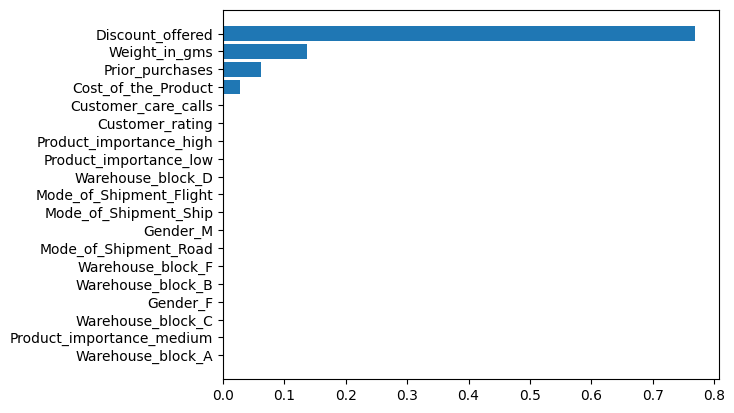

In [28]:
import matplotlib.pyplot as plt
plt.barh(importances.feature, importances.importance)